In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import noisereduce as nr
from scipy import signal

/home/emmanuel/Documents/JUPYTER/phdenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
class PreprocessingPipeline:

    def __init__(
        self,
        csv_path,
        audio_path,
        save_path,
        start=10,
        n_fft=1024,
        hop_length=256,
        n_mels=128,
        sr=44100,
        power=1,
        fmin=4000,
        fmax=8000,
        padding = 400
    ):

        self.csv_path = csv_path
        self.audio_path = audio_path
        self.save_path = save_path
        self.start = start
        self.padding = padding
        self.cutoff = fmax
        self.nyq_freq = sr/2

        self.spec_params = {
            "n_fft": n_fft,
            "hop_length": hop_length,
            "n_mels": n_mels,
            "sr": sr,
            "power": power,
            "fmin": fmin,
            "fmax": fmax
        }

        self.df = self.reader()

    def reader(self):
        df = pd.read_csv(self.csv_path)
        return df[df["Syllables"]==5]
    

    def audio_2_chirps(self):
        """Group chirps by audio file."""
        audio2data = {}
        for chirp, _, st, ed, _, _, _, audio in self.df.to_records(index=False):
            if audio not in audio2data:
                audio2data[audio] = []
            audio2data[audio].append((chirp, st, ed))
        return audio2data

    def load_audio(self, audio_file):
        """Load and normalize audio."""
        signal = librosa.load(
            os.path.join(self.audio_path, audio_file),
            sr=None,
            offset=self.start
        )[0]

    def load_audio(self, file_name):
        signal, sr = librosa.load(os.path.join(self.audio_path,file_name), sr = None, offset=self.start)
        # reduce noise
        reduced_noise = nr.reduce_noise(y=signal, sr=sr)
        # lowpass filtering
        filtered = self.butter_lowpass_filter(reduced_noise, self.cutoff, self.nyq_freq )
        # normalise signal with reduced noise between -1 and 1
        norm = filtered/np.abs(filtered).max()
        return norm

    def butter_lowpass(self, cutoff, nyq_freq, order=4):
        normal_cutoff = float(cutoff) / nyq_freq
        b, a = signal.butter(order, normal_cutoff, btype='lowpass')
        return b, a

    def butter_lowpass_filter(self, data, cutoff_freq, nyq_freq, order=4):
        # Source: https://github.com/guillaume-chevalier/filtering-stft-and-laplace-transform
        b, a = self.butter_lowpass(cutoff_freq, nyq_freq, order=order)
        y = signal.filtfilt(b, a, data)
        return y

    @staticmethod
    def extract_mel_spectrogram(signal, **kwargs):
        """Extract mel spectrogram."""
        return librosa.feature.melspectrogram(y=signal, **kwargs)

    @staticmethod
    def mel_to_db(mel_spec):
        """Convert mel spectrogram to log scale."""
        return librosa.power_to_db(mel_spec, ref=np.min)
        
    
    def pad(self, signal,max = 10687):
        
        length = len(signal)
        if length < max:
            dx = max - length
            pad_left = dx//2
            pad_right = dx-pad_left
            padded = np.pad(signal,(pad_left, pad_right), mode = "constant", constant_values=0)
        else:
            padded = signal
        return padded

    def save_feature(self, feature, file_name):
        """Save feature array."""
        save_file = os.path.join(self.save_path, file_name + ".npy")
        np.save(save_file, feature)

    def process(self):
        audio2data = self.audio_2_chirps()
        for audio_file, data in tqdm(audio2data.items()):
            signal = self.load_audio(audio_file)
            for chirp_data in data:
                chirp_name, st, ed  = chirp_data
                chirp_signal = signal[st - self.padding: ed + self.padding]
                padded = self.pad(chirp_signal)
                feature = self.extract_mel_spectrogram(padded, **self.spec_params)

                # Optional processing
                # feature = self.mel_to_db(feature)
                self.save_feature(feature, chirp_name)
                

In [14]:
if __name__ == "__main__":

    pipeline = PreprocessingPipeline(
        csv_path="../chirp_index_extraction/chirp_data.csv",
        audio_path="../audio_files/",
        save_path="5syl_chirp_arrays/",
        start=10,
        n_fft=1024,
        hop_length=256,
        n_mels=128,
        sr=44100,
        power=1,
        fmin=4000,
        fmax=8000,
        padding = 400
    )

    pipeline.process()

100%|█████████████████████████████████████████████| 7/7 [00:10<00:00,  1.56s/it]


In [15]:
 save_path = "5syl_chirp_arrays/"

In [20]:
specs = os.listdir(save_path)
spec = np.load(save_path + specs[10])

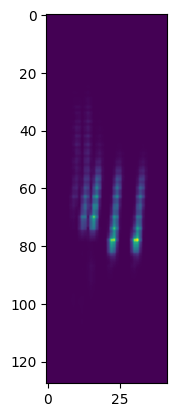

In [21]:
plt.imshow(spec)